# Homogeneous Square Domain

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('spawn')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
import pandas as pd
from igakit import cad

from ttnte.xs.benchmarks import pu239, research_reactor
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import power, LinearSolverOptions
from ttnte.cad import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Vacuum Boundary Conditions
### Define cross section library and IGA mesh

In [2]:
# Discretization
num_ordinates = 4096

# Get XS data
xs_server = pu239(num_groups=2)

In [3]:
# Create NURBS geometry
length = 6.5 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))
patch = Patch(cad.bilinear(points), "Pu-239")

# Create mesh
mesh = IGAMesh()
mesh.add_patch(patch)

# Refine mesh resolution
mesh.refine(factor=10, degree=4)

# Connect patches
mesh.connect()

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=1, reflective_boundaries=False)
  -> Patch(material=Pu-239, source=None, id=0, name=None, shape=(13, 13), backend=geomdl)

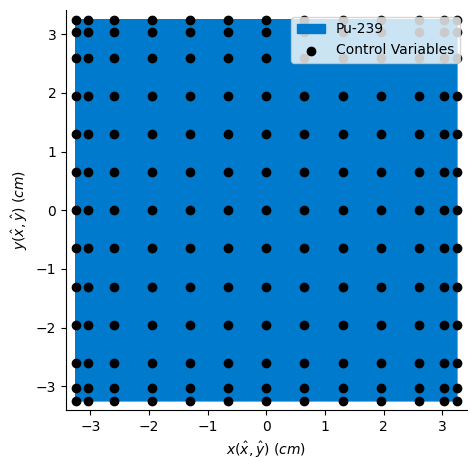

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/square_vac.png", dpi=300, transparent=True)
plt.show()

### Assemble TT operators

In [5]:
# Create operators in COO format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=True, eps=1e-5)

# Save TT information
assembler.save_info("./tt_info_vac.csv")

Running TTAssembler.build()
Discretization: N = 1024, G = 2, P = 1, A = 13, B = 13
Operators: H, S, F, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 5.78 s)
Step            Ranks                     Compression
H               3,3,3,3,2                 19820237.68
S               1,1,1,1,1                 137693697.18
F               1,1,1,1,1                 137693697.18
B_out           3,4,4,4,3                 12205146.87


### Solve

In [6]:
psi, k = power(
    T=(tts.H + tts.B_out - tts.S).round(1e-5),
    F=tts.F,
    tol=1e-8,
    maxiter=500,
    gpu_idx=0,
    lsoptions=LinearSolverOptions(
        tol=1e-10,
        maxiter=5,
        restart=30,
    )
)
psi = psi.reshape(assembler.discretization)

# Save solution
mesh.save(path="mesh_vac.hdf5", solution=psi, k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

Running power iteration on GPU 0
-- (0): k = 0.940893, Angular Flux L2-Error = 0.572524328760, Elapsed Time = 0.684 s
-- (1): k = 0.979565, Angular Flux L2-Error = 0.126191947454, Elapsed Time = 1.299 s
-- (2): k = 0.991578, Angular Flux L2-Error = 0.041591564215, Elapsed Time = 1.911 s
-- (3): k = 0.995622, Angular Flux L2-Error = 0.014747106379, Elapsed Time = 2.527 s
-- (4): k = 0.997042, Angular Flux L2-Error = 0.005382248670, Elapsed Time = 3.141 s
-- (5): k = 0.997552, Angular Flux L2-Error = 0.001985943683, Elapsed Time = 3.755 s
-- (6): k = 0.997737, Angular Flux L2-Error = 0.000738374282, Elapsed Time = 4.366 s
-- (7): k = 0.997805, Angular Flux L2-Error = 0.000278569069, Elapsed Time = 4.981 s
-- (8): k = 0.997830, Angular Flux L2-Error = 0.000109231275, Elapsed Time = 5.594 s
-- (9): k = 0.997839, Angular Flux L2-Error = 0.000046159935, Elapsed Time = 6.208 s
-- (10): k = 0.997842, Angular Flux L2-Error = 0.000023665233, Elapsed Time = 6.819 s
-- (11): k = 0.997844, Angular 

-- (0): k = 0.94088667, Angular Flux L2-Error = 0.58017077, Elapsed Time = 1.69


-- (1): k = 0.97956642, Angular Flux L2-Error = 0.12623772, Elapsed Time = 3.274


-- (2): k = 0.99157738, Angular Flux L2-Error = 0.04148378, Elapsed Time = 4.867


-- (3): k = 0.99562239, Angular Flux L2-Error = 0.01468513, Elapsed Time = 6.452


...

-- (14): k = 0.99784436, Angular Flux L2-Error = 2.8e-07, Elapsed Time = 23.925


-- (15): k = 0.99784439, Angular Flux L2-Error = 1.2e-07, Elapsed Time = 25.513


-- (16): k = 0.99784439, Angular Flux L2-Error = 7e-08, Elapsed Time = 27.101


-- (17): k = 0.9978444, Angular Flux L2-Error = 4e-08, Elapsed Time = 28.688


-- (18): k = 0.9978444, Angular Flux L2-Error = 1e-08, Elapsed Time = 29.259
-- Converged: k = 0.9978444, Elapsed Time = 29.259


### Plotting and comparison to OpenMC

In [7]:
# Get OpenMC solution
k_mc = [0.9979554743352164, 3.1026419209814144e-05]
phi_mc = np.load("./openmc/data/mesh_flux.npy")
phi_mc_stdev = np.load("./openmc/data/mesh_stdev.npy")

# Ensure OpenMC solution is normalized
phi_mc_stdev /= np.linalg.norm(phi_mc.flatten(), 2)
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print(f"TDIGA k = {k}")
print(f"OpenMC k = {k_mc[0]} +/- {k_mc[1]}")
print(f"Error = {k - k_mc[0]} pcm or {(k - k_mc[0]) / k_mc[1]} stdevs from OpenMC")

TDIGA k = 0.9978443997158906
OpenMC k = 0.9979554743352164 +/- 3.1026419209814144e-05
Error = -0.00011107461932580165 pcm or -3.5800012426399177 stdevs from OpenMC


<Figure size 640x480 with 0 Axes>

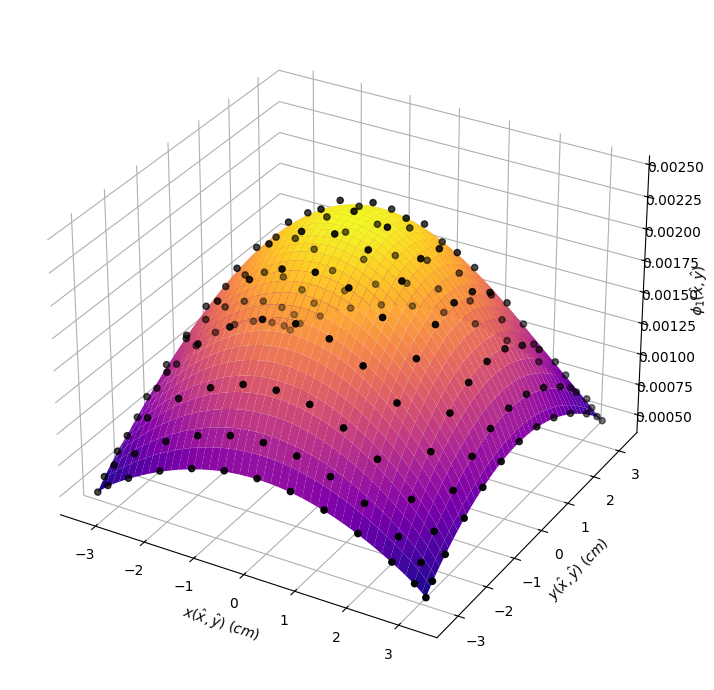

<Figure size 640x480 with 0 Axes>

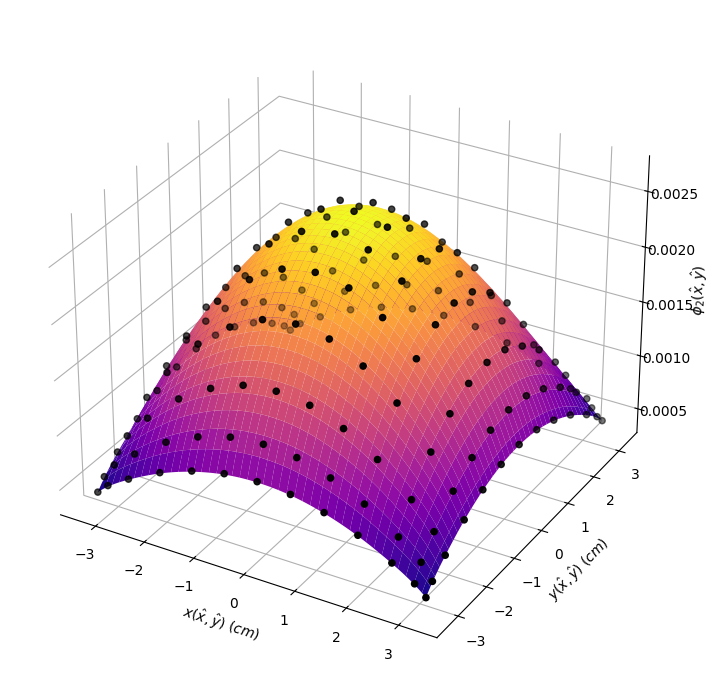

In [8]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(5, 5))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_3d=True, figsize=(7, 7))
    ax.set_zlabel(rf"$\phi_{g + 1}" + r"(\hat{x}, \hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_vac.png", dpi=300, transparent=True)
    plt.show()

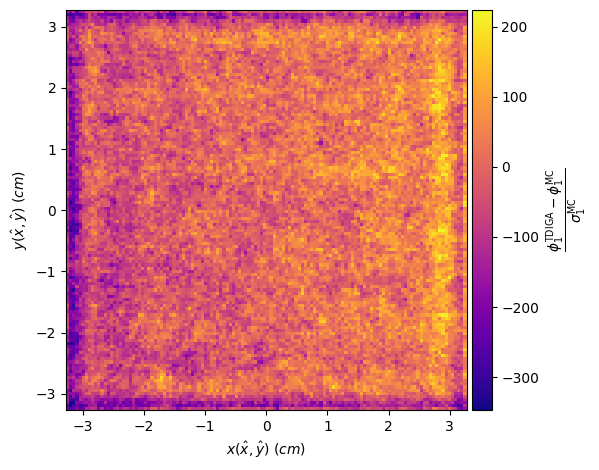

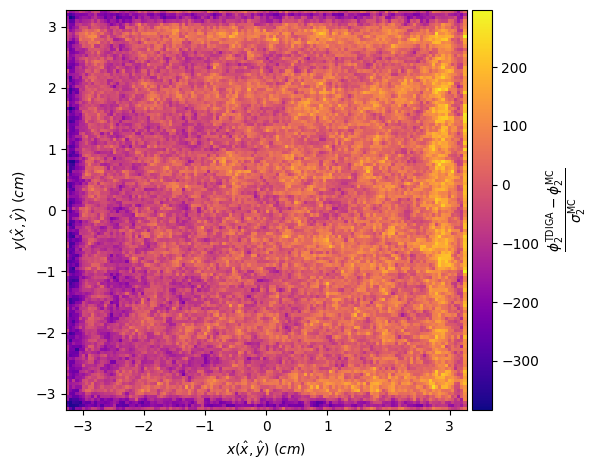

In [9]:
# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

# Regular mesh
X, Y = np.meshgrid(
    np.linspace(-length / 2, length / 2, phi_mc.shape[1]),
    np.linspace(-length / 2, length / 2, phi_mc.shape[2]),
)

# Calculate z-score within each voxel
z = np.abs((phi_avg - phi_mc) / phi_mc_stdev)
stats = {
    "Group": list(range(1, xs_server.num_groups + 1)) + ["Total"],
    **{
        name: np.zeros(xs_server.num_groups + 1) 
        for name in 
        ["Minimum", "Q1", "Median", "Q2", "Maximum", "Mean", "L2 Error"]
    },
}

for g in range(xs_server.num_groups):
    # Plot z-score
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(X, Y, z[g,], cmap="plasma")
    divider = make_axes_locatable(ax)
    cbar = plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
    )
    cbar.set_label(
        r"$\frac{|\phi_" 
        + str(g + 1) + r"^{\text{TDIGA}} - \phi_" 
        + str(g + 1) + r"^{\text{MC}}|}{|\sigma_" 
        + str(g + 1) + r"^{\text{MC}}|}$",
        size=14
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_zscore.png", dpi=300, transparent=True)
    plt.show()

    # Get some stats
    stats["Minimum"][g] = np.min(z[g,])
    stats["Q1"][g] = np.percentile(z[g,], 25)
    stats["Median"][g] = np.median(z[g,])
    stats["Q2"][g] = np.percentile(z[g,], 75)
    stats["Maximum"][g] = np.max(z[g,])
    stats["Mean"][g] = np.mean(z[g,])

stats["Minimum"][-1] = np.min(z)
stats["Q1"][-1] = np.percentile(z, 25)
stats["Median"][-1] = np.median(z)
stats["Q2"][-1] = np.percentile(z, 75)
stats["Maximum"][-1] = np.max(z)
stats["Mean"][-1] = np.mean(z)

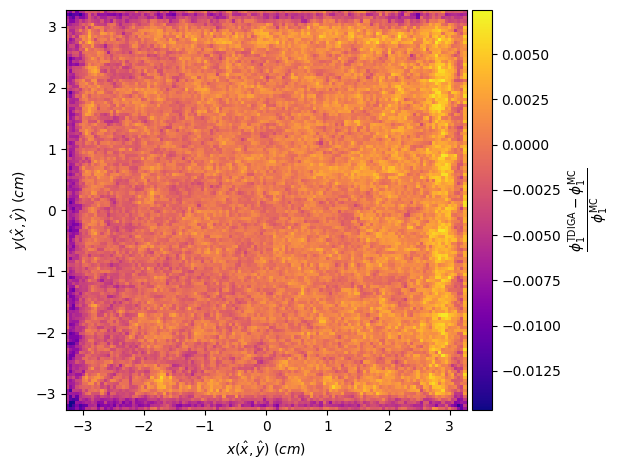

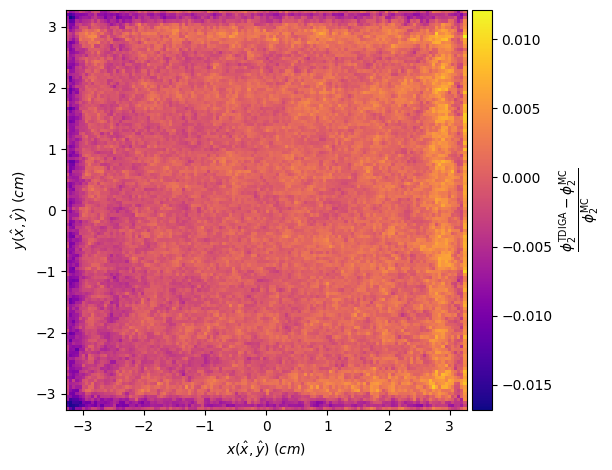

,Group,Minimum,Q1,Median,Q2,Maximum,Mean,L2 Error
0,1,-347.422319,-48.919773,-1.982959,41.453748,223.627261,-7.095587,0.001734
1,2,-384.337225,-52.936742,-1.535619,46.702226,296.986145,-6.560852,0.001807
2,Total,-384.337225,-50.842280,-1.801714,43.800228,296.986145,-6.828220,0.002505


In [10]:
relative_error = np.abs((phi_avg - phi_mc) / phi_mc)

for g in range(xs_server.num_groups):
    # Plot relative error
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(X, Y, relative_error[g,], cmap="plasma")
    divider = make_axes_locatable(ax)
    cbar = plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
    )
    cbar.set_label(
        r"$\frac{|\phi_" 
        + str(g + 1) + r"^{\text{TDIGA}} - \phi_" 
        + str(g + 1) + r"^{\text{MC}}|}{|\phi_" 
        + str(g + 1) + r"^{\text{MC}}|}$",
        size=14
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_error.png", dpi=300, transparent=True)
    plt.show()

    # Calculate L2-error
    stats["L2 Error"][g] = (
        np.linalg.norm((phi_avg[g,] - phi_mc[g,]).flatten(), 2) 
        / np.linalg.norm(phi_mc[g,].flatten(), 2)
    )

# Calculate L2-error
stats["L2 Error"][-1] = (
    np.linalg.norm(stats["L2 Error"][:-1], 2)
)
pd.DataFrame(stats)

## Reflective Boundary Conditions

### Build IGA mesh

In [11]:
# Create NURBS geometry
length = 3.591204 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))

# Create mesh
mesh = IGAMesh()
mesh.add_patch(Patch(cad.bilinear(points), "Pu-239"))

# Refine mesh resolution
mesh.refine(factor=[3, 7], degree=4)

# Connect mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_conditions(("top", "bottom"))

# Finalize patches
mesh.finalize()
mesh

IGAMesh(id=1, name=None, num_patches=1, reflective_boundaries=True)
  -> Patch(material=Pu-239, source=None, id=1, name=None, shape=(7, 11), backend=geomdl)

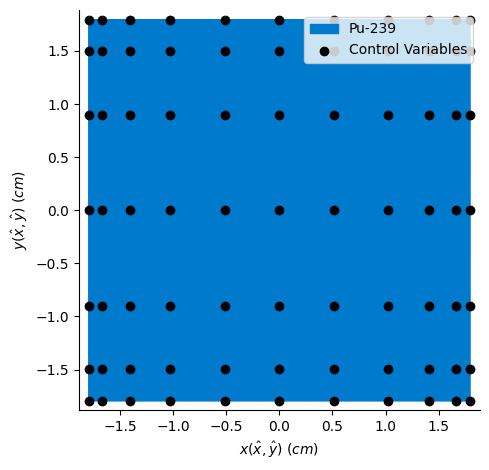

In [12]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/square_ref.png", dpi=300, transparent=True)
plt.show()

### Assemble TT operators

In [13]:
# Initialize builder
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=True, eps=1e-5)

# Save TT information
assembler.save_info("./tt_info_ref.csv")

Running TTAssembler.build()
Discretization: N = 1024, G = 2, P = 1, A = 7, B = 11
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 6.49 s)
Step            Ranks                     Compression
H               3,3,3,3,2                 4756700.16
S               1,1,1,1,1                 35424541.90
F               1,1,1,1,1                 35424541.90
B_out           3,4,4,4,3                 3021264.54
B_in            2,2,2,2,1                 10742128.91


### Solve and check eigenvalue

In [14]:
psi, k = power(
    T=(tts.H - tts.S + tts.B_out - tts.B_in),
    F=tts.F,
    tol=1e-8,
    maxiter=500,
    gpu_idx=0,
    lsoptions=LinearSolverOptions(
        tol=1e-10,
        maxiter=5,
        restart=30,
    )
)
psi = psi.reshape(assembler.discretization)

# Save solution
mesh.save(path="mesh_ref.hdf5", solution=psi, k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

# Calculate eigenvalue error
print("keff error: {} pcm".format((k - 1) * 1e5))

Running power iteration on GPU 0
-- (0): k = 0.982688, Angular Flux L2-Error = 0.567607762745, Elapsed Time = 0.360 s
-- (1): k = 0.996353, Angular Flux L2-Error = 0.054871649561, Elapsed Time = 0.707 s
-- (2): k = 0.998865, Angular Flux L2-Error = 0.011279339406, Elapsed Time = 1.053 s
-- (3): k = 0.999371, Angular Flux L2-Error = 0.002817501487, Elapsed Time = 1.397 s
-- (4): k = 0.999478, Angular Flux L2-Error = 0.001040536077, Elapsed Time = 1.744 s
-- (5): k = 0.999501, Angular Flux L2-Error = 0.000533126730, Elapsed Time = 2.090 s
-- (6): k = 0.999506, Angular Flux L2-Error = 0.000334620041, Elapsed Time = 2.435 s
-- (7): k = 0.999507, Angular Flux L2-Error = 0.000222932881, Elapsed Time = 2.785 s
-- (8): k = 0.999507, Angular Flux L2-Error = 0.000161734434, Elapsed Time = 3.132 s
-- (9): k = 0.999507, Angular Flux L2-Error = 0.000123521427, Elapsed Time = 3.478 s
-- (10): k = 0.999507, Angular Flux L2-Error = 0.000091797129, Elapsed Time = 3.828 s
-- (11): k = 0.999507, Angular 

-- (0): k = 0.98268535, Angular Flux L2-Error = 0.56328998, Elapsed Time = 1.39


-- (1): k = 0.99635349, Angular Flux L2-Error = 0.05390381, Elapsed Time = 2.765


-- (2): k = 0.9988636, Angular Flux L2-Error = 0.01082176, Elapsed Time = 4.144


-- (3): k = 0.99937131, Angular Flux L2-Error = 0.00230919, Elapsed Time = 5.52


...

-- (63): k = 0.99950722, Angular Flux L2-Error = 2e-08, Elapsed Time = 88.022


-- (64): k = 0.99950722, Angular Flux L2-Error = 2e-08, Elapsed Time = 89.39


-- (65): k = 0.99950722, Angular Flux L2-Error = 1e-08, Elapsed Time = 90.762


-- (66): k = 0.99950722, Angular Flux L2-Error = 1e-08, Elapsed Time = 92.132


-- (67): k = 0.99950722, Angular Flux L2-Error = 1e-08, Elapsed Time = 93.498
-- (68): k = 0.99950722, Angular Flux L2-Error = 0.0, Elapsed Time = 93.582
-- Converged: k = 0.99950722, Elapsed Time = 93.582
keff error: -49.27805742007685 pcm


### Plot solution

<Figure size 640x480 with 0 Axes>

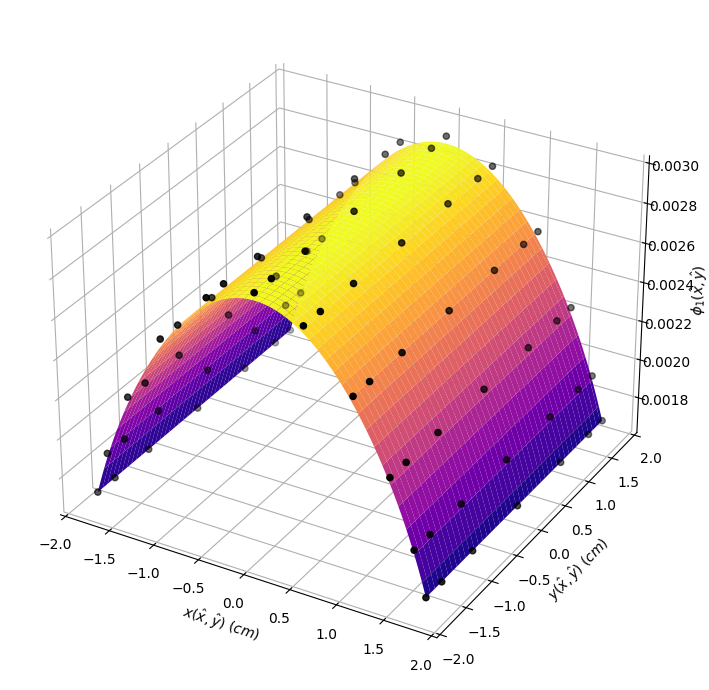

<Figure size 640x480 with 0 Axes>

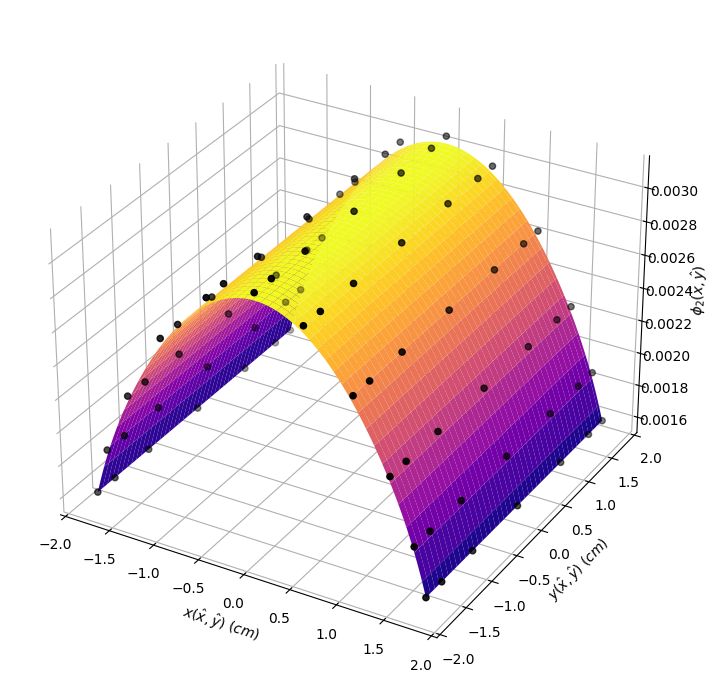

In [15]:
# Iterate through groups and plot
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_3d=True, figsize=(7, 7))
    ax.set_zlabel(rf"$\phi_{g + 1}" + r"(\hat{x}, \hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_ref.png", dpi=300, transparent=True)
    plt.show()

## Linearly Anisotropic

### Define cross section library and IGA mesh

In [16]:
# Get XS data
xs_server = research_reactor(is_anisotropic=True)

# Create NURBS geometry
length = 9.4959 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))

# Create mesh
mesh = IGAMesh()
mesh.add_patch(Patch(cad.bilinear(points), "Research Reactor"))

# Refine mesh resolution
mesh.refine(factor=[5, 7], degree=3)

# Connect patches
mesh.connect()

# Define boundary conditions
mesh.set_reflective_conditions(("left", "top", "bottom"))

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=2, name=None, num_patches=1, reflective_boundaries=True)
  -> Patch(material=Research Reactor, source=None, id=2, name=None, shape=(8, 10), backend=geomdl)

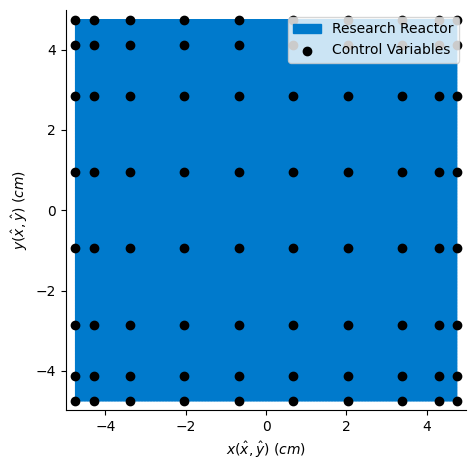

In [17]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/square_anisotropic.png", dpi=300, transparent=True)
plt.show()

### Assemble TT operators

In [18]:
# Initialize builder
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=True, eps=1e-5)

# Save TT information
assembler.save_info("./tt_info_anisotropic.csv")

Running TTAssembler.build()
Discretization: N = 1024, G = 2, P = 1, A = 8, B = 10
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 2.76 s)
Step            Ranks                     Compression
H               3,3,3,3,2                 5087859.29
S               3,3,2,1,1                 6611710.74
F               1,1,1,1,1                 38568312.64
B_out           3,4,4,4,3                 3215566.08
B_in            3,3,3,3,2                 5087859.29


### Solve

In [19]:
psi, k = power(
    T=(tts.H - tts.S + tts.B_out - tts.B_in),
    F=tts.F,
    tol=1e-8,
    maxiter=500,
    gpu_idx=0,
    lsoptions=LinearSolverOptions(
        tol=1e-10,
        maxiter=5,
        restart=30,
    )
)
psi = psi.reshape(assembler.discretization)

# Save solution
mesh.save(path="mesh_anisotropic.hdf5", solution=psi, k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

# Calculate eigenvalue error
print("keff error: {} pcm".format((k - 1) * 1e5))

Running power iteration on GPU 0
-- (0): k = 0.904309, Angular Flux L2-Error = 1.428368922109, Elapsed Time = 0.427 s
-- (1): k = 0.986175, Angular Flux L2-Error = 0.140284510825, Elapsed Time = 0.851 s
-- (2): k = 0.997483, Angular Flux L2-Error = 0.021770782970, Elapsed Time = 1.276 s
-- (3): k = 0.999493, Angular Flux L2-Error = 0.004065141565, Elapsed Time = 1.694 s
-- (4): k = 0.999871, Angular Flux L2-Error = 0.000781992265, Elapsed Time = 2.114 s
-- (5): k = 0.999944, Angular Flux L2-Error = 0.000153747958, Elapsed Time = 2.538 s
-- (6): k = 0.999958, Angular Flux L2-Error = 0.000032151467, Elapsed Time = 2.965 s
-- (7): k = 0.999960, Angular Flux L2-Error = 0.000008113566, Elapsed Time = 3.395 s
-- (8): k = 0.999961, Angular Flux L2-Error = 0.000002998681, Elapsed Time = 3.828 s
-- (9): k = 0.999961, Angular Flux L2-Error = 0.000001057128, Elapsed Time = 4.251 s
-- (10): k = 0.999961, Angular Flux L2-Error = 0.000000456047, Elapsed Time = 4.682 s
-- (11): k = 0.999961, Angular 

-- (0): k = 0.9043517, Angular Flux L2-Error = 1.21615946, Elapsed Time = 1.389


-- (1): k = 0.98619096, Angular Flux L2-Error = 0.1402703, Elapsed Time = 2.768


-- (2): k = 0.99748486, Angular Flux L2-Error = 0.02174288, Elapsed Time = 4.149


-- (3): k = 0.99949277, Angular Flux L2-Error = 0.00405318, Elapsed Time = 5.532


...

-- (7): k = 0.9999604, Angular Flux L2-Error = 5.55e-06, Elapsed Time = 10.817


-- (8): k = 0.99996092, Angular Flux L2-Error = 1.07e-06, Elapsed Time = 11.589


-- (9): k = 0.99996102, Angular Flux L2-Error = 2.1e-07, Elapsed Time = 12.126


-- (10): k = 0.99996104, Angular Flux L2-Error = 4e-08, Elapsed Time = 12.45
-- (11): k = 0.99996104, Angular Flux L2-Error = 1e-08, Elapsed Time = 12.639
-- Converged: k = 0.99996104, Elapsed Time = 12.639


keff error: -3.8958270256017613 pcm


### Plot solution

<Figure size 640x480 with 0 Axes>

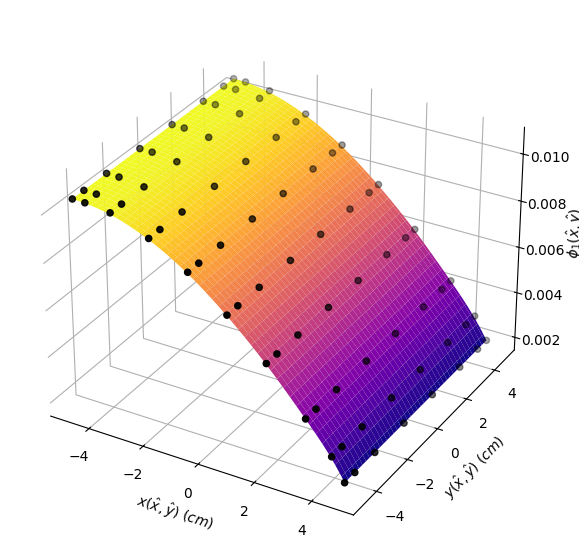

<Figure size 640x480 with 0 Axes>

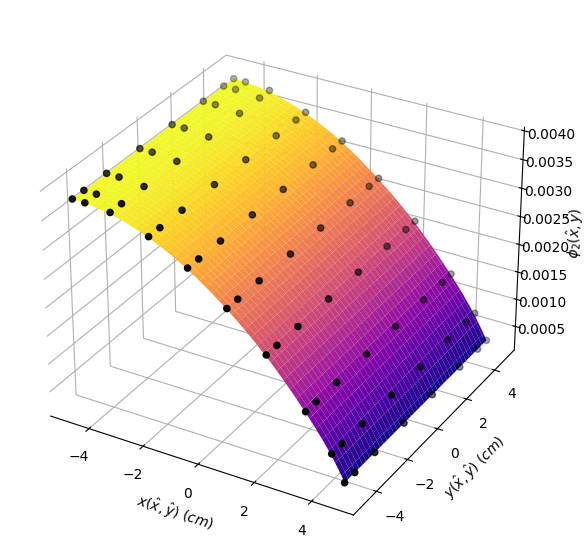

In [20]:
# Iterate through groups and plot
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_3d=True, figsize=(7, 7))
    ax.set_zlabel(rf"$\phi_{g + 1}" + r"(\hat{x}, \hat{y})$")
    plt.savefig(f"./figs/phi_{g + 1}_anisotropic.png", dpi=300, transparent=True)
    plt.show()